<font color="#CA3532"><h1 align="left">**XAI en Aprendizaje por Refuerzo**</h1></font>
<font color="#6E6E6E"><h2 align="left">**Multiarmed Bandits Contextuales**</h2></font>

In [1]:
COLAB = True

if COLAB:
  aux = "'https://docs.google.com/uc?export=download&id=1cXazQiXQ23DLTDz2o0K4MrjRsE--8-ye&confirm=t'"
  !wget $aux -O ./cs_construccion.csv

  aux = "'https://docs.google.com/uc?export=download&id=1BSr6AtATF6bncQuJ83k8HQixjLym2waq&confirm=t'"
  !wget $aux -O ./DataDictionary.csv

--2026-07-03 14:20:27--  https://docs.google.com/uc?export=download&id=1cXazQiXQ23DLTDz2o0K4MrjRsE--8-ye&confirm=t
Resolving docs.google.com (docs.google.com)... 64.233.180.102, 64.233.180.139, 64.233.180.101, ...
Connecting to docs.google.com (docs.google.com)|64.233.180.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1cXazQiXQ23DLTDz2o0K4MrjRsE--8-ye&export=download [following]
--2026-07-03 14:20:27--  https://drive.usercontent.google.com/download?id=1cXazQiXQ23DLTDz2o0K4MrjRsE--8-ye&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 64.233.180.132, 2607:f8b0:4004:c21::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|64.233.180.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4922656 (4.7M) [application/octet-stream]
Saving to: ‘./cs_construccion.csv’

./cs_construccion.c 100%[===================>]   4.6

In [2]:
import pandas as pd
pd.options.display.max_columns = None

df = pd.read_csv("cs_construccion.csv")
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.090577,59,0,0.289273,7466.0,17,0,2,0,1.0
1,0,0.019327,74,0,1.505535,541.0,16,0,1,0,0.0
2,0,0.670039,34,0,0.081489,7816.0,9,0,0,0,0.0
3,0,1.000000,66,0,0.209132,6000.0,4,0,1,0,0.0
4,0,0.138060,65,1,100.000000,NaN,2,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
104995,0,0.386104,64,2,0.426491,10916.0,23,0,2,0,0.0
104996,0,0.634398,65,0,0.644908,7000.0,18,0,3,0,0.0
104997,0,0.057559,44,0,0.288714,15000.0,8,0,1,0,2.0
104998,0,0.395824,48,0,0.157955,3500.0,7,1,0,0,2.0


In [3]:
!head DataDictionary.csv

;Variable Name;Description;Type
0;SeriousDlqin2yrs;Person experienced 90 days past due delinquency or worse ;Y/N
1;RevolvingUtilizationOfUnsecuredLines;Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits;percentage
2;age;Age of borrower in years;integer
3;NumberOfTime30-59DaysPastDueNotWorse;Number of times borrower has been 30-59 days past due but no worse in the last 2 years.;integer
4;DebtRatio;Monthly debt payments, alimony,living costs divided by monthy gross income;percentage
5;MonthlyIncome;Monthly income;real
6;NumberOfOpenCreditLinesAndLoans;Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards);integer
7;NumberOfTimes90DaysLate;Number of times borrower has been 90 days or more past due.;integer
8;NumberRealEstateLoansOrLines;Number of mortgage and real estate loans including home equity lines of credit;integer


In [4]:
pd.options.display.max_colwidth = None
dicc = pd.read_csv("DataDictionary.csv", sep=";").drop("Unnamed: 0", axis=1).set_index("Variable Name")
dicc

,Description,Type
Variable Name,,
SeriousDlqin2yrs,Person experienced 90 days past due delinquency or worse,Y/N
RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits,percentage
age,Age of borrower in years,integer
NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days past due but no worse in the last 2 years.,integer
DebtRatio,"Monthly debt payments, alimony,living costs divided by monthy gross income",percentage
MonthlyIncome,Monthly income,real
NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards),integer
NumberOfTimes90DaysLate,Number of times borrower has been 90 days or more past due.,integer
NumberRealEstateLoansOrLines,Number of mortgage and real estate loans including home equity lines of credit,integer


In [12]:
df = df[df["age"]>0]

In [13]:
df.describe().T[["count", "min", "max", "mean", "std"]]

,count,min,max,mean,std
SeriousDlqin2yrs,104999.0,0.0,1.0,0.066839,0.249744
RevolvingUtilizationOfUnsecuredLines,104999.0,0.0,22198.0,6.147021,217.682402
age,104999.0,21.0,109.0,52.222107,14.764871
NumberOfTime30-59DaysPastDueNotWorse,104999.0,0.0,98.0,0.419928,4.189010
DebtRatio,104999.0,0.0,329664.0,354.163856,1999.464575
MonthlyIncome,84204.0,0.0,3008750.0,6700.447532,15368.301089
NumberOfOpenCreditLinesAndLoans,104999.0,0.0,58.0,8.440299,5.130907
NumberOfTimes90DaysLate,104999.0,0.0,98.0,0.265107,4.166043
NumberRealEstateLoansOrLines,104999.0,0.0,54.0,1.016419,1.133979
NumberOfTime60-89DaysPastDueNotWorse,104999.0,0.0,98.0,0.239288,4.151878


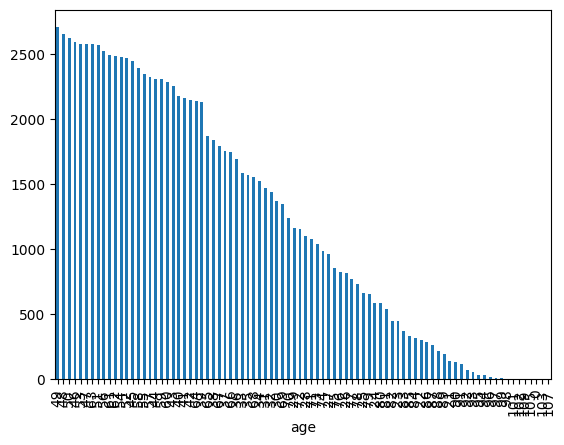

In [6]:
df["age"].value_counts().plot(kind="bar");

In [11]:
(df["age"]>=80).sum()

np.int64(4035)

In [ ]:
dfdf["age"]>80

In [14]:
aux = df.isna().sum()
100*aux[aux>0]/len(df)

,0
MonthlyIncome,19.804951
NumberOfDependents,2.607644


In [19]:
100*df["SeriousDlqin2yrs"].value_counts()/len(df)

,count
SeriousDlqin2yrs,
0,93.316127
1,6.683873


In [18]:
aux1 = df[df["MonthlyIncome"].isna()]
100*aux1["SeriousDlqin2yrs"].value_counts()/len(aux1)

,count
SeriousDlqin2yrs,
0,94.508295
1,5.491705


In [20]:
aux1 = df[~df["MonthlyIncome"].isna()]
100*aux1["SeriousDlqin2yrs"].value_counts()/len(aux1)

,count
SeriousDlqin2yrs,
0,93.021709
1,6.978291


In [21]:
df = df.dropna(subset=["MonthlyIncome"])

In [22]:
df.describe().T[["count", "min", "max", "mean", "std"]]

,count,min,max,mean,std
SeriousDlqin2yrs,84204.0,0.0,1.0,0.069783,0.254782
RevolvingUtilizationOfUnsecuredLines,84204.0,0.0,22000.0,5.466585,206.558552
age,84204.0,21.0,103.0,51.220168,14.429200
NumberOfTime30-59DaysPastDueNotWorse,84204.0,0.0,98.0,0.380481,3.488310
DebtRatio,84204.0,0.0,60212.0,26.193099,410.744017
MonthlyIncome,84204.0,0.0,3008750.0,6700.447532,15368.301089
NumberOfOpenCreditLinesAndLoans,84204.0,0.0,58.0,8.741057,5.156455
NumberOfTimes90DaysLate,84204.0,0.0,98.0,0.211249,3.454888
NumberRealEstateLoansOrLines,84204.0,0.0,54.0,1.050793,1.153131
NumberOfTime60-89DaysPastDueNotWorse,84204.0,0.0,98.0,0.186345,3.437176


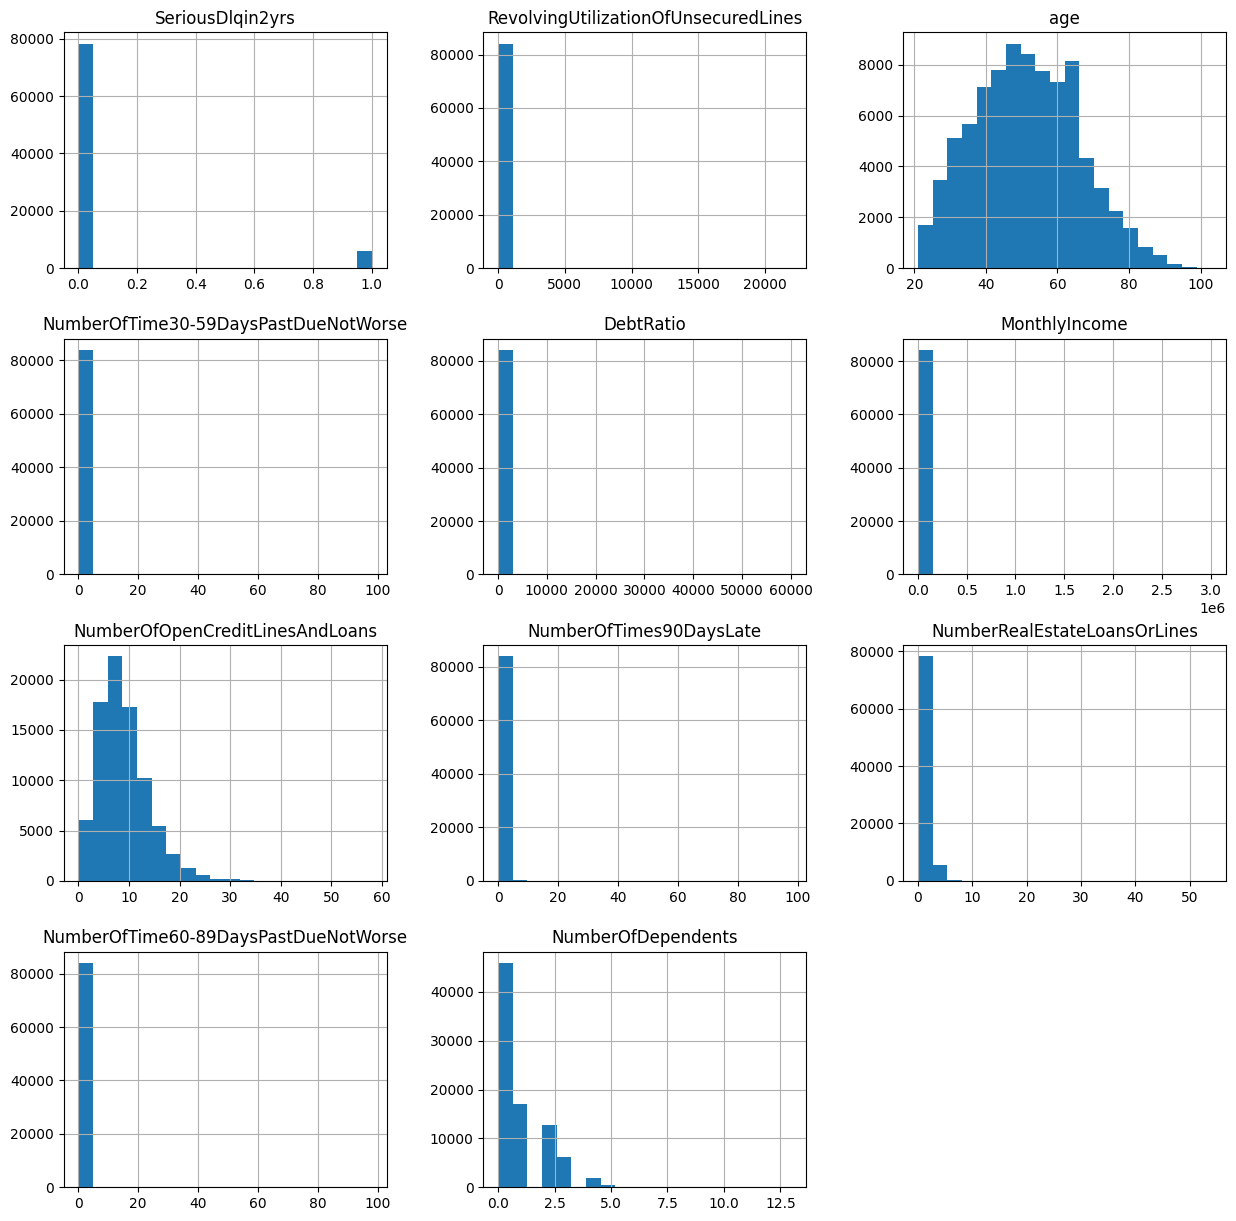

In [27]:
df.hist(figsize=(15,15), bins=20);

In [28]:
df["NumberOfTime30-59DaysPastDueNotWorse"].value_counts()

,count
NumberOfTime30-59DaysPastDueNotWorse,
0,69983
1,9490
2,2774
3,1090
4,424
5,196
98,100
6,89
7,27


In [29]:
df["NumberOfTime60-89DaysPastDueNotWorse"].value_counts()

,count
NumberOfTime60-89DaysPastDueNotWorse,
0,79850
1,3329
2,643
3,190
98,100
4,53
5,18
6,12
7,4


In [30]:
df["NumberOfTimes90DaysLate"].value_counts()

,count
NumberOfTimes90DaysLate,
0,79479
1,3043
2,857
3,381
4,170
98,100
5,73
6,44
7,18


In [31]:
((df["NumberOfTime30-59DaysPastDueNotWorse"]==98) & (df["NumberOfTime60-89DaysPastDueNotWorse"]==98)&  (df["NumberOfTimes90DaysLate"]==98)).sum()

np.int64(100)

In [33]:
((df["NumberOfTime30-59DaysPastDueNotWorse"]==96) & (df["NumberOfTime60-89DaysPastDueNotWorse"]==96)&  (df["NumberOfTimes90DaysLate"]==96)).sum()

np.int64(3)

In [34]:
df = df[df["NumberOfTimes90DaysLate"]<96]

In [35]:
df.describe().T[["count", "min", "max", "mean", "std"]]

,count,min,max,mean,std
SeriousDlqin2yrs,84101.0,0.0,1.0,0.069143,0.253699
RevolvingUtilizationOfUnsecuredLines,84101.0,0.0,22000.0,5.472055,206.684943
age,84101.0,21.0,103.0,51.238986,14.420024
NumberOfTime30-59DaysPastDueNotWorse,84101.0,0.0,12.0,0.260996,0.715225
DebtRatio,84101.0,0.0,60212.0,26.225170,410.994443
MonthlyIncome,84101.0,0.0,3008750.0,6705.544476,15376.657043
NumberOfOpenCreditLinesAndLoans,84101.0,0.0,58.0,8.751739,5.150563
NumberOfTimes90DaysLate,84101.0,0.0,15.0,0.091557,0.488549
NumberRealEstateLoansOrLines,84101.0,0.0,54.0,1.052080,1.153251
NumberOfTime60-89DaysPastDueNotWorse,84101.0,0.0,8.0,0.066622,0.332392


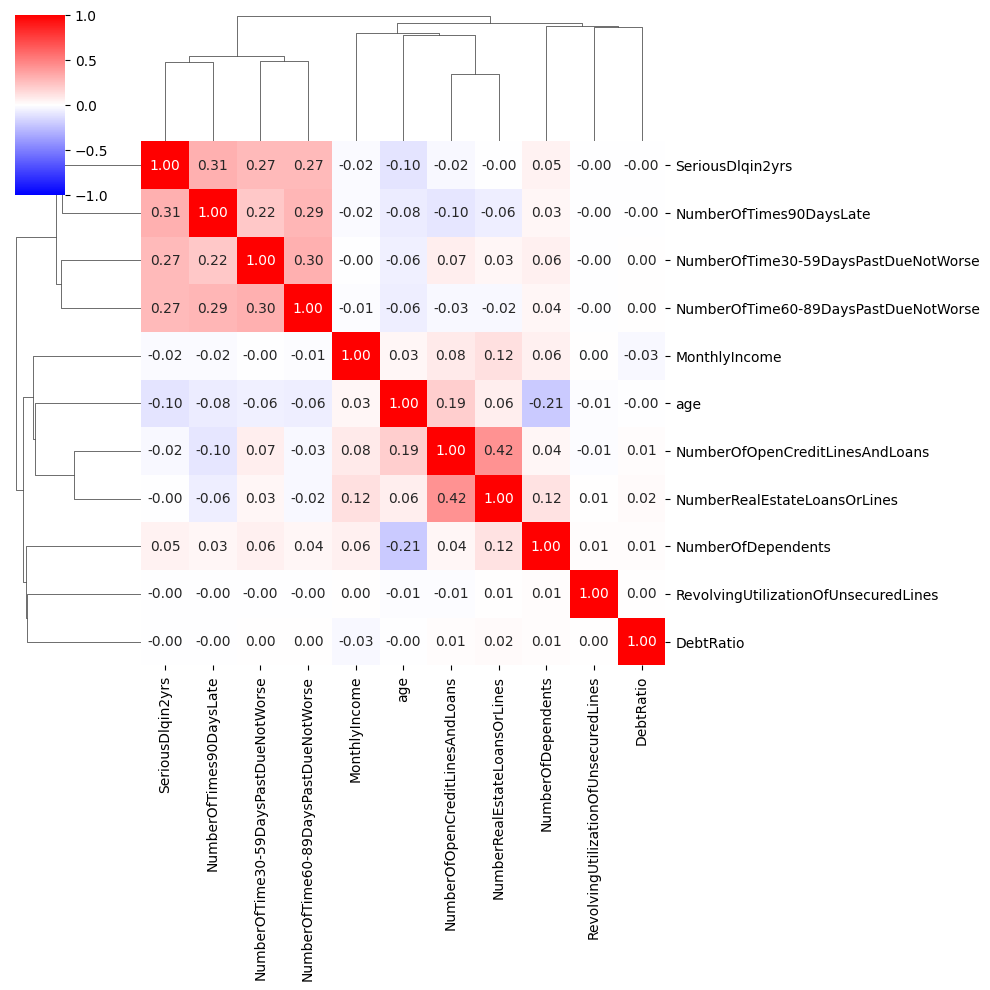

In [42]:
import seaborn as sns
sns.clustermap(df.corr(), cmap="bwr", vmin=-1, annot=True, fmt=".2f");

In [57]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df.drop("SeriousDlqin2yrs", axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

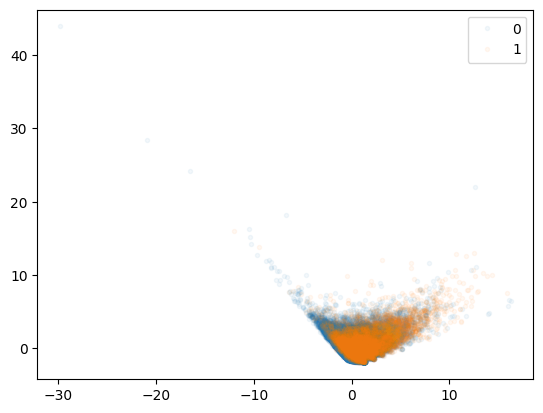

In [58]:
import matplotlib.pyplot as plt
y = df['SeriousDlqin2yrs']
plt.plot(X_pca[y==0,0], X_pca[y==0,1], ".", label="0", alpha=0.05)
plt.plot(X_pca[y==1,0], X_pca[y==1,1], ".", label="1", alpha=0.05)
plt.legend();

In [59]:
import plotly.express as px

df_aux = df.copy()
df_aux["PC1"] = X_pca[:,0]
df_aux["PC2"] = X_pca[:,1]
df_aux["PC3"] = X_pca[:,2]

px.scatter(df_aux, x="PC1", y="PC2", color="SeriousDlqin2yrs", hover_data=df_aux.columns)

Output hidden; open in https://colab.research.google.com to view.

In [63]:
fig = px.scatter_3d(df_aux, x="PC1", y="PC2", z="PC3", color="SeriousDlqin2yrs", hover_data=df_aux.columns)
fig.write_html("im1.html")

## Modelo supervisado clásico

In [ ]:
df

In [ ]:
df = df[["worst perimeter", "worst concavity", "target"]]

In [ ]:
df

In [ ]:
df["target"].value_counts()/len(df)

In [ ]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.3, random_state=1, stratify=df["target"])

In [ ]:
df_train["target"].value_counts()/len(df_train)

In [ ]:
df_test["target"].value_counts()/len(df_test)

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,8))
sns.clustermap(df_train.corr(), cmap="bwr", vmin=-1);

In [ ]:
X_train = df_train.drop("target", axis=1)
y_train = df_train["target"]

X_test = df_test.drop("target", axis=1)
y_test = df_test["target"]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=1, max_depth=3)
model.fit(X_train, y_train)

In [ ]:
model.score(X_train, y_train), model.score(X_test, y_test)

In [ ]:
model.feature_importances_

In [ ]:
import matplotlib.pyplot as plt
plt.barh(X_train.columns, model.feature_importances_);

In [ ]:
model.predict(X_test)

In [ ]:
y_test.values

In [ ]:
(model.predict(X_test) == y_test.values).mean() # predecir la clase más probable, esto es óptimo si los errores penalizan igual

In [ ]:
PENALIZACION_FALSO_POSITIVO = 1  # El modelo dice 0 (maligno) pero es realmente 1 (benigno)
PENALIZACION_FALSO_NEGATIVO = 10 # El modelo dice 1 (benigno) pero es realmente 0 (maligno)

In [ ]:
import numpy as np
penalizaciones_medias = []

prob_clase_1 = model.predict_proba(X_test)[:,1]
umbrales = np.unique(prob_clase_1)
for umbral_clase1 in umbrales:
  predicciones = (prob_clase_1 > umbral_clase1).astype(int)
  penalizacion_media = ((predicciones == 1) & (y_test.values==0))*PENALIZACION_FALSO_NEGATIVO
  penalizacion_media += ((predicciones == 0) & (y_test.values==1))*PENALIZACION_FALSO_POSITIVO
  penalizacion_media = np.mean(penalizacion_media)
  penalizaciones_medias.append(penalizacion_media)

plt.plot(umbrales, penalizaciones_medias)
plt.xlabel("Umbral de probabilidad clase 1")
plt.ylabel("Penalización media");

In [ ]:
predicciones

## Enfoque del problema con Aprendizaje por Refuerzo

In [ ]:
class persona:
  def __init__(self, nombre, edad):
    self.name = nombre
    self.age = edad
  def saludar(self):
    print("Hola, mi nombre es", self.name, "y tengo", self.age, "años")
  def cumple_anyos(self):
    self.age += 1

In [ ]:
persona1 = persona("Juan", 36)
persona2 = persona("Pedro", 10)
persona1.saludar()

In [ ]:
persona2.saludar()

In [ ]:
persona1.cumple_anyos()
persona1.saludar()
persona2.saludar()

In [ ]:
np.random.randint(10)

In [ ]:
class entorno_tumores:
  def __init__(self, df, penalizacion_FP, penalizacion_FN):
    self.df = df
    self.penalizacion_FP = penalizacion_FP
    self.penalizacion_FN = penalizacion_FN
  def nuevo_paciente(self):
    self.i = np.random.randint(len(self.df)) # elijo una fila al azar
  def datos_paciente(self):
    return self.df.iloc[self.i].drop("target")
  def act(self, accion): # accion: mi predicción. Devuelve el refuerzo (premio/castigo)
    if accion == 0: # (mi predicción es 0)
      if self.df.iloc[self.i]["target"] == 0:
        return 0 # no hay penalización
      else: # target real es 1, FP
        return -self.penalizacion_FP
    else: # accion es 1 (mi predicción es 1)
      if self.df.iloc[self.i]["target"] == 1:
        return 0 # no hay penalización
      else: # target real es 0, FN
        return -self.penalizacion_FN

In [ ]:
entorno_train = entorno_tumores(df_train, PENALIZACION_FALSO_POSITIVO, PENALIZACION_FALSO_NEGATIVO)
entorno_test  = entorno_tumores(df_test, PENALIZACION_FALSO_POSITIVO, PENALIZACION_FALSO_NEGATIVO)

In [ ]:
entorno_train.nuevo_paciente()
print(entorno_train.i)
entorno_train.datos_paciente().values

In [ ]:
df_train.iloc[117].values

In [ ]:
# Benchmark: médico random

N = 10000
suma_refuerzos = 0
for _ in range(N):
  entorno_train.nuevo_paciente()
  prediccion = np.random.randint(2)
  refuerzo = entorno_train.act(prediccion)
  suma_refuerzos += refuerzo

suma_refuerzos / N

In [ ]:
COLAB = True

In [ ]:
if COLAB:
  aux = "'https://docs.google.com/uc?export=download&id=1F7iIl3Uy3t3kd-5qV8dSp5IUCUfWBPJV&confirm=t'"
  !wget $aux -O ./spacebandits.zip
  !unzip -qq -o ./spacebandits
  !rm ././spacebandits.zip

  aux = "'https://docs.google.com/uc?export=download&id=1dbP2HKFTVyj1n2MsUl1E1a9e6HriqHtM&confirm=t'"
  !wget $aux -O ./libreria_aux_arboles.py

  aux = "'https://docs.google.com/uc?export=download&id=1XUZcx1Uyfw3ieI_h5tJvzmlorQEd0ySy&confirm=t'"
  !wget $aux -O ./my_library.py

In [ ]:
from space_bandits import LinearBandits

In [ ]:
model = LinearBandits(num_actions=2, num_features=len(X_train.columns))

In [ ]:
from tqdm import tqdm

In [ ]:
prediccion

In [ ]:
# Modelo multiarmed bandit
# -0.335

N = 1000
suma_refuerzos = 0
for _ in tqdm(range(N)):
  entorno_train.nuevo_paciente()
  datos_paciente = entorno_train.datos_paciente().values
  prediccion = model.predict(datos_paciente)[0]
  refuerzo = entorno_train.act(prediccion)
  suma_refuerzos += refuerzo
  model.update(datos_paciente, prediccion, refuerzo)

suma_refuerzos / N

In [ ]:
# Modelo multiarmed bandit en test
# -0.289
N = 1000
suma_refuerzos = 0
for _ in tqdm(range(N)):
  entorno_test.nuevo_paciente()
  datos_paciente = entorno_test.datos_paciente().values
  prediccion = model.predict(datos_paciente)[0]
  refuerzo = entorno_test.act(prediccion)
  suma_refuerzos += refuerzo

suma_refuerzos / N

In [ ]:
model.predict(datos_paciente)

In [ ]:
# Modelo surrogado

# "Gemelo digital" del que queremos interpretar
# Pero mucho más sencillo. Idealmente: "caja blanca"

# Genero con mi modelo caja negra (el que quiero explicar): X_caja_negra, y_predicha_caja_negra
#
# modelo_surrogado = DecisionTreeClassifier()
# modelo_surrogado.fit(X_caja_negra, y_predicha_caja_negra)

In [ ]:
X_caja_negra = X_test.values
y_predicha_caja_negra = model.predict(X_caja_negra)

In [ ]:
y_predicha_caja_negra

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz

surrogate_model = DecisionTreeClassifier(max_leaf_nodes=4)
surrogate_model.fit(X_caja_negra, y_predicha_caja_negra)
surrogate_model.score(X_caja_negra, y_predicha_caja_negra) # cómo de buena es la réplica

In [ ]:
# Ejercicio: vuelve a entrenar el modelo usando solo las variables worst perimeter y worst concavity, y chequea si es igual o mejor

In [ ]:
from graphviz import Source

display(Source( export_graphviz(surrogate_model, out_file=None,
                                feature_names=X_test.columns,
                                #class_names=cluster_names,
                                filled=True, rounded=True,
                                special_characters=True,
                                impurity=True,
                                leaves_parallel=True,
                                rotate=False,
                                #node_ids=True
                                )))

In [ ]:
from graphviz import Source

display(Source( export_graphviz(surrogate_model, out_file=None,
                                feature_names=X_test.columns,
                                #class_names=cluster_names,
                                filled=True, rounded=True,
                                special_characters=True,
                                impurity=True,
                                leaves_parallel=True,
                                rotate=False,
                                #node_ids=True
                                )))

In [ ]:
from my_library import get_rules_from_tree
action_names = ["Salida modelo caja negra={}".format(x) for x in surrogate_model.classes_]
rules = get_rules_from_tree(surrogate_model, X_test.columns, action_names, X_caja_negra, y_predicha_caja_negra)

print(len(rules), "rules:\n")
for item in rules.items():
    print('\033[1m' + "* ", item[1][0], '\033[0m')
    for c in item[1][1]:
        print("     "+c[0]+":", c[1], "cases (%.2f%%)" % (100*c[2]))

DOS ACCIONES: 0: predecir tumor maligno. 1: predecir tumor benigno

In [ ]:
ACCION_PREDECIR_MALIGNO = 0
ACCION_PREDECIR_BENIGNO = 1

El objetivo es construir un Multiarmed Bandit Contextual, ya bien sea lineal, o neuronal, para optimizar el reward total en este problema.

Para ello repite y adapta los pasos en el notebook citado.

Aplica también IA Explicable (XAI), como en ese notebook, para intentar interpretar la solución obtenida.

In [ ]:
from libreria_aux_arboles import tree_to_code, tree_to_pseudo
from graphviz import Source

startbold = '\033[1m'
endbold = '\033[0m'
#tree_to_code(surrogate_model, attributes_names, start_bold=startbold, end_bold=endbold)

#display(Source( export_graphviz(clf, out_file=None,
#                                feature_names=attributes_names,
#                                #class_names=cluster_names,
#                                filled=True, rounded=True,
#                                special_characters=True,
#                                impurity=True,
#                                leaves_parallel=True,
#                                rotate=False,
#                                node_ids=True)))